In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("libraries imported")


libraries imported


In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.columns = ['sepal_length','sepal_width','petal_length','petal_width']
df['species'] = iris.target
df['species_name'] = df['species'].map({0:'Setosa', 1:'Versicolor', 2:'Virginica'})

print("Dataset Shape:", df.shape)
print(f"Classes: {df['species_name'].unique()}")
print(f"Class Distribution:\n{df['species_name'].value_counts()}")
print(f"\nFeature Names: {list(df.columns[:4])}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
df.head(8)


Dataset Shape: (150, 6)
Classes: ['Setosa' 'Versicolor' 'Virginica']
Class Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

Feature Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Missing Values: 0


,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa


In [3]:
print("Statistical Summary:")
df.describe().round(2)


Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


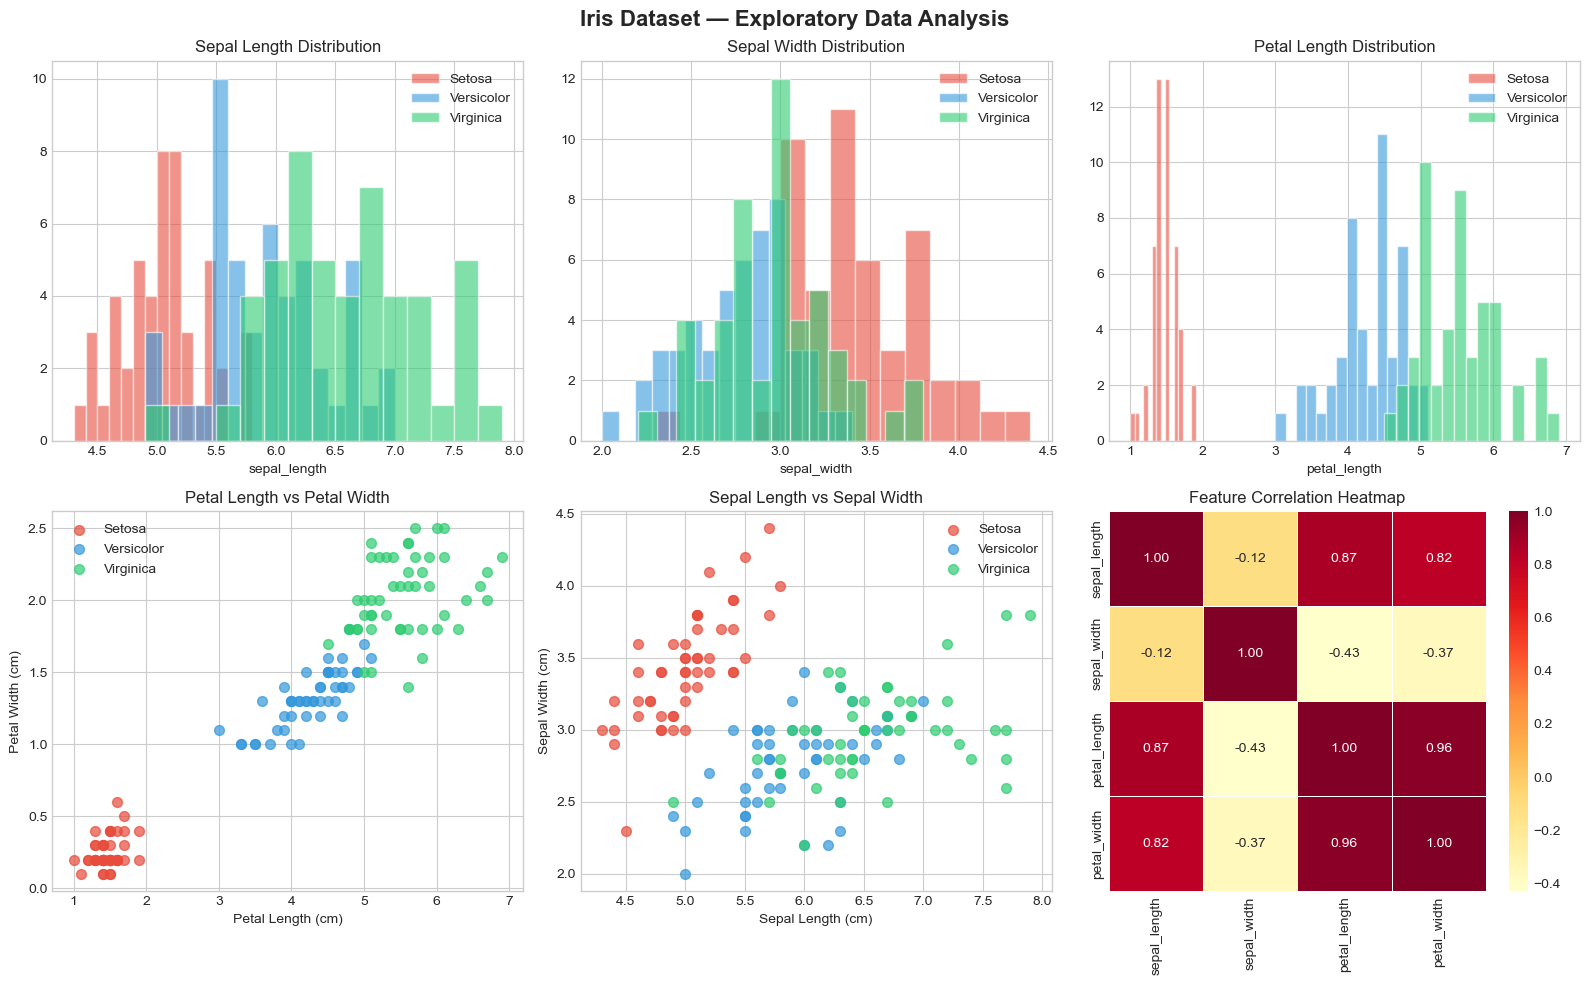

EDA complete!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Iris Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

features = ['sepal_length','sepal_width','petal_length','petal_width']
colors = {'Setosa':'#e74c3c','Versicolor':'#3498db','Virginica':'#2ecc71'}

for i, feat in enumerate(features[:3]):
    ax = axes[0, i]
    for species, grp in df.groupby('species_name'):
        ax.hist(grp[feat], bins=15, alpha=0.6, label=species, color=colors[species],
                edgecolor='white')
    ax.set_title(f'{feat.replace("_"," ").title()} Distribution')
    ax.set_xlabel(feat)
    ax.legend()

for species, grp in df.groupby('species_name'):
    axes[1,0].scatter(grp['petal_length'], grp['petal_width'],
                      label=species, color=colors[species], alpha=0.7, s=50)
axes[1,0].set_title('Petal Length vs Petal Width')
axes[1,0].set_xlabel('Petal Length (cm)')
axes[1,0].set_ylabel('Petal Width (cm)')
axes[1,0].legend()

for species, grp in df.groupby('species_name'):
    axes[1,1].scatter(grp['sepal_length'], grp['sepal_width'],
                      label=species, color=colors[species], alpha=0.7, s=50)
axes[1,1].set_title('Sepal Length vs Sepal Width')
axes[1,1].set_xlabel('Sepal Length (cm)')
axes[1,1].set_ylabel('Sepal Width (cm)')
axes[1,1].legend()

corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('iris_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA complete!")


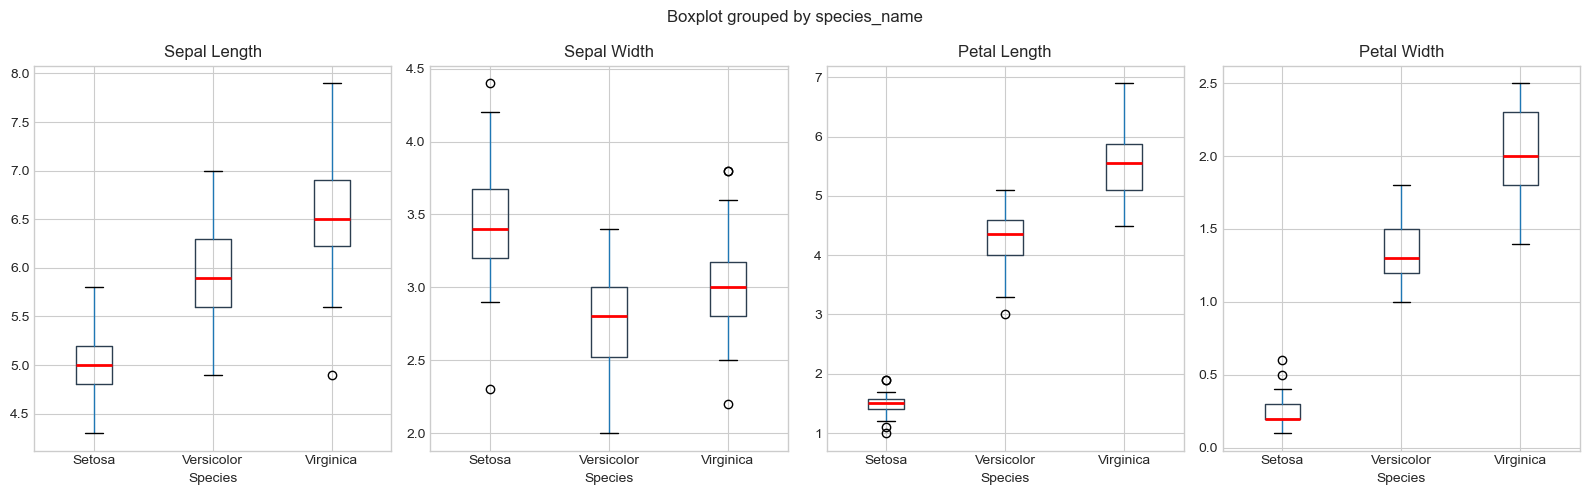

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Feature Distribution by Species (Boxplots)', fontsize=14, fontweight='bold')

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='species_name', ax=axes[i],
               boxprops=dict(color='#2c3e50'), medianprops=dict(color='red', lw=2))
    axes[i].set_title(feat.replace('_',' ').title())
    axes[i].set_xlabel('Species')
    plt.sca(axes[i])
    plt.title(feat.replace('_',' ').title())

plt.tight_layout()
plt.savefig('iris_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
print("Key Observations:")
print("=" * 55)
print("1. Setosa is LINEARLY SEPARABLE from the other two")
print("   classes based on petal measurements alone.")
print()
print("2. Petal Length & Width are the most discriminative")
print("   features — high correlation with species.")
print()
print("3. Sepal width shows significant overlap between")
print("   Versicolor and Virginica.")
print()
print("4. Petal dimensions are the most important features")
print("   for classification.")

for feat in features:
    r = df[feat].corr(df['species'])
    print(f"  {feat:18s}: correlation with species = {r:.3f}")


Key Observations:
1. Setosa is LINEARLY SEPARABLE from the other two
   classes based on petal measurements alone.

2. Petal Length & Width are the most discriminative
   features — high correlation with species.

3. Sepal width shows significant overlap between
   Versicolor and Virginica.

4. Petal dimensions are the most important features
   for classification.
  sepal_length      : correlation with species = 0.783
  sepal_width       : correlation with species = -0.427
  petal_length      : correlation with species = 0.949
  petal_width       : correlation with species = 0.957


In [7]:
X = df[features]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")


Training samples: 120
Test samples:     30


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=1.0, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    uses_scale = name not in ['Decision Tree', 'Random Forest', 'Gradient Boosting']
    Xtr = X_train_sc if uses_scale else X_train.values
    Xte = X_test_sc  if uses_scale else X_test.values
    
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(model,
        X_train_sc if uses_scale else X_train.values,
        y_train, cv=skf, scoring='accuracy')
    
    results[name] = {
        'accuracy': acc, 'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(), 'preds': preds, 'model': model
    }
    print(f"{name:22s} | Test Acc: {acc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Logistic Regression    | Test Acc: 0.9333 | CV: 0.9583 ± 0.0264
Decision Tree          | Test Acc: 0.9333 | CV: 0.9417 ± 0.0204
Random Forest          | Test Acc: 0.9000 | CV: 0.9500 ± 0.0312
SVM                    | Test Acc: 0.9667 | CV: 0.9667 ± 0.0167
KNN (k=5)              | Test Acc: 0.9333 | CV: 0.9583 ± 0.0264
Gradient Boosting      | Test Acc: 0.9667 | CV: 0.9500 ± 0.0312


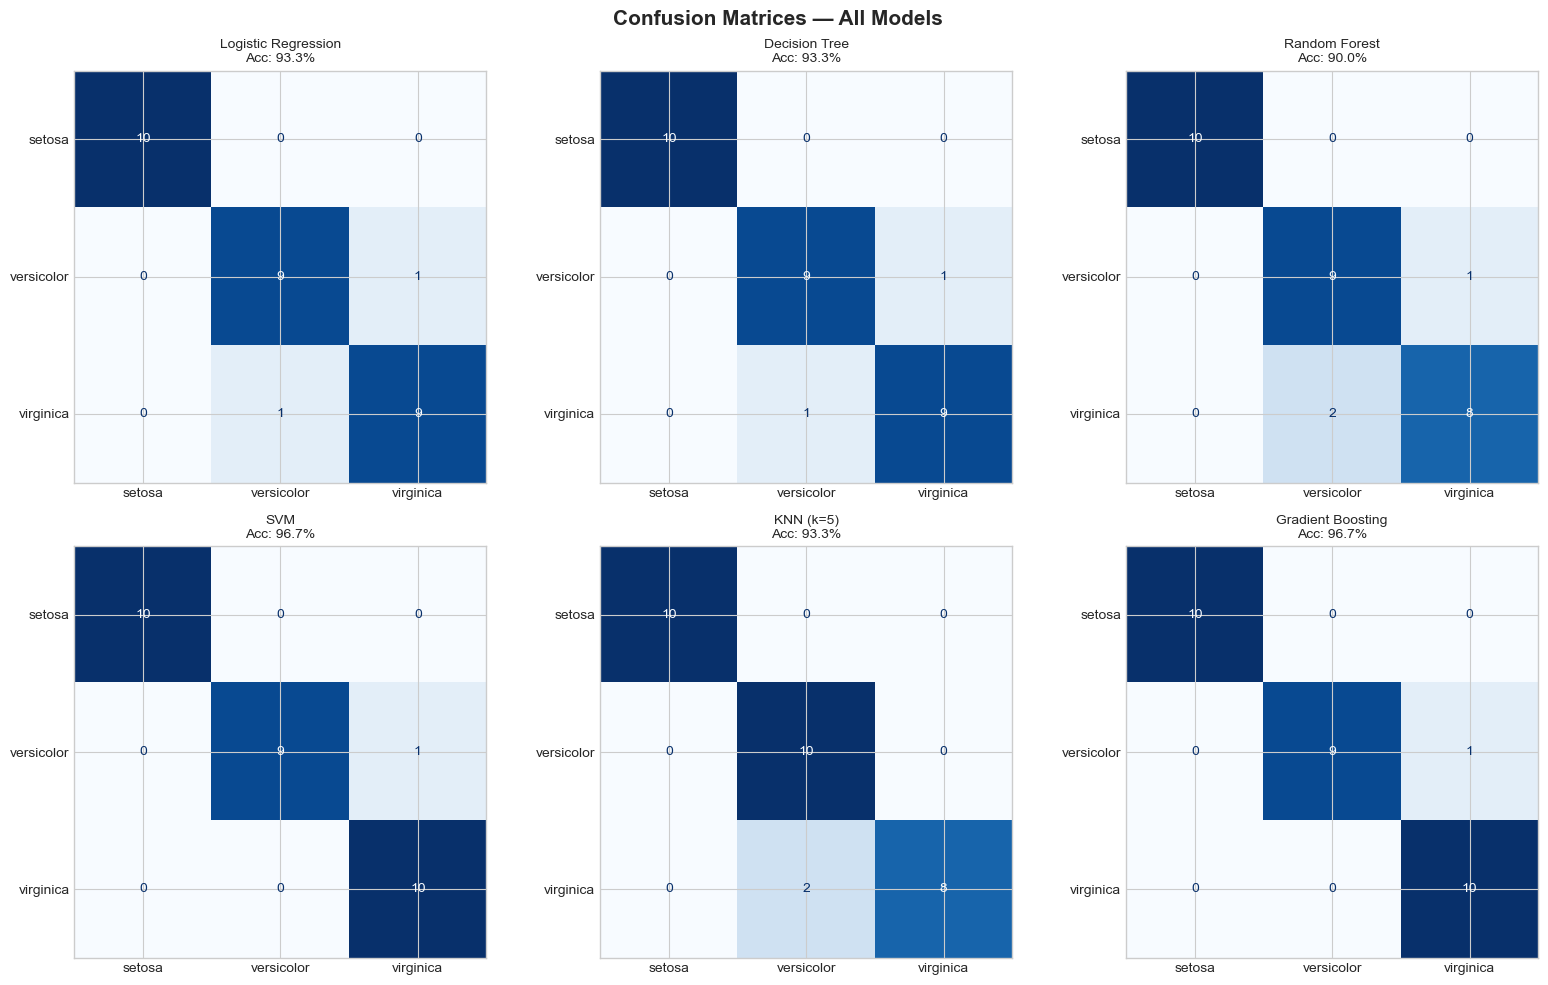

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

class_names = iris.target_names

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = res['accuracy']
    ax.set_title(f'{name}\nAcc: {acc:.1%}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


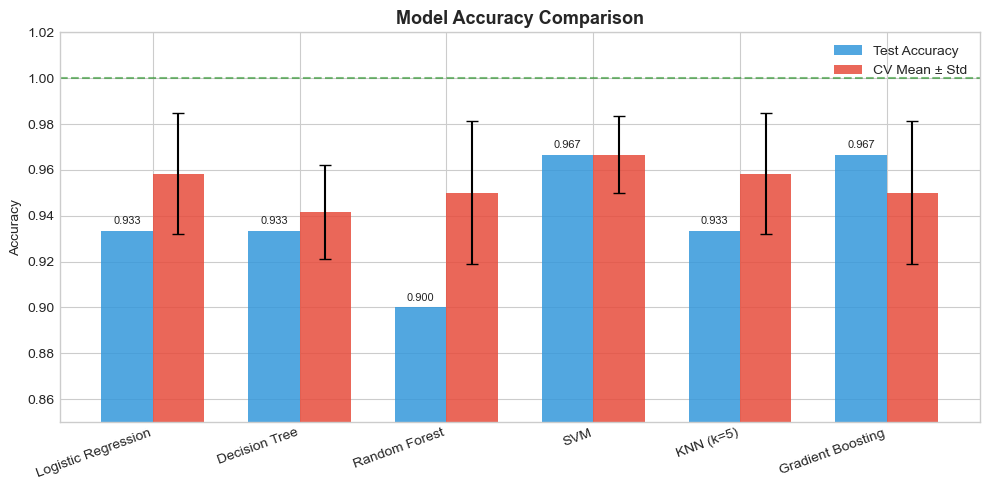

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]

x = np.arange(len(names))
w = 0.35
bars1 = ax.bar(x - w/2, accs, w, label='Test Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, cv_means, w, yerr=cv_stds, capsize=4,
               label='CV Mean ± Std', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [12]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]
print(f"Best Model: {best_name}")
print(f"Test Accuracy: {best['accuracy']:.4f} ({best['accuracy']*100:.1f}%)")
print(f"CV Accuracy:   {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best['preds'], target_names=class_names))


Best Model: SVM
Test Accuracy: 0.9667 (96.7%)
CV Accuracy:   0.9667 ± 0.0167

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

